In [1]:
import re

import pandas as pd
import nltk
import numpy as np
import warnings

from nltk import probability

warnings.filterwarnings("ignore")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\zamanov\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
df = pd.read_csv('labeledTrainData.tsv', sep='\t')
df.head()

,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


In [4]:
%%time
def preprocessing(df):
    df['review'] = df.review.str.lower()
    df["document_sentences"] = df.review.str.split(".")
    df["tokenized_sentences"] = list(map(lambda sentence: list(map(nltk.word_tokenize, sentence)), df.document_sentences))
    df["tokenized_sentences"] = list(map(lambda word: list(filter(lambda lst: lst, word)), df.tokenized_sentences))
preprocessing(df)



CPU times: total: 14.7 s
Wall time: 14.9 s


In [8]:
from sklearn.model_selection import train_test_split
train, test, y_train, y_test = train_test_split(df.drop(columns='sentiment'), df['sentiment'], test_size=0.2, random_state=42)

In [10]:
voc = []
for sen in train.tokenized_sentences:
    voc.extend(sen)
print(f"len(voc) = ", len(voc))
print(f"len(train) = ", len(train))
print(f"len(test) = ", len(test))

print(f"len(y_train) = ", len(y_train))
print(f"len(y_test) = ", len(y_test))


len(voc) =  250290
len(train) =  20000
len(test) =  5000
len(y_train) =  20000
len(y_test) =  5000


In [13]:
import gensim
from gensim.models import Word2Vec, word2vec

num_features = 300
min_word_count = 3
num_workers = 4
context = 5
downsampling = 1e-3

Word2Vec_model = Word2Vec(
    sentences=voc,
    sg=1,
    hs=0,
    workers=num_workers,
    min_count=min_word_count,
    window=context,
    sample=downsampling,
    vector_size=num_features,
    negative=5,
    epochs=6,
)


In [14]:
def sentence_vectors(model, sentences):
    words = np.concatenate(sentences)
    model_vocab = set(model.wv.key_to_index.keys())
    sentence_vector = np.zeros(model.vector_size, dtype=np.float32)
    n_words = 0
    for word in words:
        if word in model_vocab:
            sentence_vector+= model.wv[word]
            n_words+=1
    if n_words > 0:
        sentence_vector/= n_words
    return sentence_vector
train["sentence_vector"] = list(map(lambda sen_group: sentence_vectors(Word2Vec_model, sen_group), train.tokenized_sentences))




In [17]:
def vectors_to_feats(df, ndim):
    index = []
    for i in range(ndim):
        df[f"w2v_{i}"] = df["sentence_vector"].apply(lambda x: x[i])
        index.append(f"w2v_{i}")
    return df[index]
X_train = vectors_to_feats(train, num_features)
X_train.head()

,w2v_0,w2v_1,w2v_2,w2v_3,w2v_4,w2v_5,w2v_6,w2v_7,w2v_8,w2v_9,...,w2v_290,w2v_291,w2v_292,w2v_293,w2v_294,w2v_295,w2v_296,w2v_297,w2v_298,w2v_299
23311,-0.008171,0.073301,0.058960,0.091500,0.030419,-0.137957,0.149156,0.350920,0.006805,-0.037708,...,0.029117,0.116582,0.065859,-0.006685,0.127134,0.129663,0.081986,-0.008330,0.109523,0.021311
23623,-0.015253,0.110240,0.064127,0.123464,0.021402,-0.121571,0.120223,0.383300,-0.021042,-0.052194,...,0.022583,0.155298,0.087374,-0.027104,0.151811,0.176964,0.061436,-0.021986,0.112313,0.037144
1020,0.011412,0.114514,0.078444,0.103607,0.048180,-0.149177,0.112650,0.357311,0.025057,-0.049299,...,0.030316,0.163264,0.093427,-0.048024,0.131851,0.160305,0.069246,-0.022457,0.096540,0.050164
12645,-0.048558,0.082246,0.074255,0.078984,0.019033,-0.158368,0.111968,0.349086,-0.008608,-0.022391,...,0.090844,0.127353,0.086828,-0.016962,0.133564,0.169361,0.086168,-0.024091,0.109330,0.025550
1533,-0.044775,0.062133,0.065295,0.007843,0.101841,-0.142729,0.141190,0.286014,-0.011968,-0.106491,...,0.074802,0.112689,0.122317,0.169642,0.152743,0.129159,0.031695,-0.035008,0.087101,-0.038765


In [18]:
test["sentence_vector"] = list(map(lambda sen_group: sentence_vectors(Word2Vec_model, sen_group), test.tokenized_sentences))
X_test = vectors_to_feats(test, num_features)
X_test.head()

,w2v_0,w2v_1,w2v_2,w2v_3,w2v_4,w2v_5,w2v_6,w2v_7,w2v_8,w2v_9,...,w2v_290,w2v_291,w2v_292,w2v_293,w2v_294,w2v_295,w2v_296,w2v_297,w2v_298,w2v_299
6868,-0.075239,0.095211,0.065023,0.085720,0.016587,-0.127986,0.111602,0.375484,-0.037187,-0.008510,...,0.099359,0.141455,0.074367,-0.008566,0.107415,0.157850,0.047965,-0.054889,0.131454,0.011680
24016,-0.031573,0.083075,0.069692,0.078253,0.035005,-0.136745,0.132764,0.338344,0.010192,-0.043172,...,0.048690,0.128389,0.078163,0.011800,0.130452,0.159173,0.069717,-0.034980,0.107771,0.027745
9668,-0.044993,0.061098,0.094148,0.102638,-0.001732,-0.155093,0.174408,0.283562,-0.050914,0.002681,...,0.079356,0.120601,0.052098,-0.038980,0.136252,0.165461,0.089974,-0.046763,0.112354,0.002190
13640,-0.073713,0.048199,0.113632,0.053040,-0.008321,-0.153010,0.155912,0.353811,-0.011302,-0.021105,...,0.095776,0.111911,0.106065,-0.029441,0.136856,0.163018,0.095523,-0.015329,0.110706,0.051212
14018,-0.069167,0.060244,0.088481,0.090878,-0.005026,-0.154238,0.163470,0.343056,-0.042611,0.008289,...,0.062660,0.126705,0.069088,-0.036663,0.145810,0.147078,0.104425,0.003905,0.164197,0.033743


In [19]:
from  sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [20]:
from sklearn.metrics import roc_auc_score, confusion_matrix
roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])

0.9334190342834203

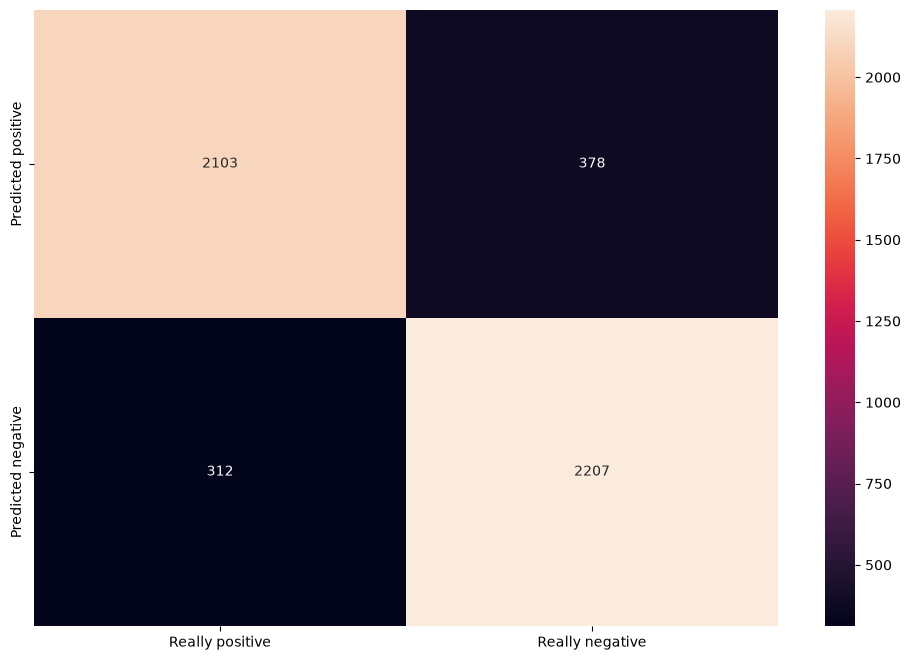

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

df_cm = pd.DataFrame(confusion_matrix(y_test, lr.predict(X_test)),
                     index=["Predicted positive", "Predicted negative"],
                     columns=["Really positive", "Really negative"])
plt.figure(figsize=(12, 8))
sns.heatmap(df_cm, annot=True, fmt="g")
plt.show()


In [23]:
voc_df = []
for sen in df.tokenized_sentences:
    voc_df.extend(sen)
print(f"len of voc_df = {len(voc_df)}")
print(f"len of df = {len(df)}")

len of voc_df = 313267
len of df = 25000


In [24]:
%%time
Word2Vec_model_df = Word2Vec(
    sentences=voc_df,
    sg=1,
    hs=0,
    workers=num_features,
    min_count=min_word_count,
    window=context,
    sample=downsampling,
    vector_size=num_features,
    epochs=6,
    negative=5,
)

CPU times: total: 4min 36s
Wall time: 29.4 s


In [25]:
df["sentence_vector"] = list(map(lambda sen: sentence_vectors(Word2Vec_model_df, sen), df.tokenized_sentences))
df = vectors_to_feats(df, num_features)
y = pd.read_csv("labeledTrainData.tsv", sep='\t')["sentiment"].values

In [26]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(df, y)

from  sklearn.model_selection import ShuffleSplit, cross_val_score
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
cv_score = cross_val_score(lr, df, y, cv=cv, scoring="roc_auc")
print(f"cv_score = {cv_score}, roc_auc_score = {cv_score.mean()}, std_score = {cv_score.std()}")

cv_score = [0.9358683  0.93529074 0.93631018 0.92876384 0.93669596 0.9330628
 0.93651601 0.93812264 0.93288488 0.93610304], roc_auc_score = 0.9349618390091561, std_score = 0.0025651282968532497


In [30]:
from nltk.util import pr
def predict_sentiment(review:str, w2v_model, lr_model):
    review_lower = review.lower()
    sentences = review_lower.split('.')
    review_tokenized = [nltk.word_tokenize(sentence) for sentence in sentences]
    review_tokenized = [sentence for sentence in review_tokenized if sentence]
    review_vector = sentence_vectors(w2v_model, review_tokenized)
    review_features = review_vector.reshape(1, -1)
    prediction = lr_model.predict(review_features)[0]
    probability = lr_model.predict_proba(review_features)[0]
    return prediction, probability


def analyze_review(review):
    prediction, probability = predict_sentiment(review, Word2Vec_model_df, lr)
    print("*"*70)
    if prediction == 1:
        sentiment = "positive"
    else:
        sentiment = "negative"
    print(f"Sentiment: {sentiment}")
    print(f"Probability: {probability}")
    print(f"Probability negative: {probability[0]:.2f}")
    print(f"Probability positive: {probability[1]:.2f}")
    return prediction, probability

In [43]:
my_review = """
Mortal Kombat II delivers exactly what fans might expect: plenty of action, brutal fights, and nonstop energy. The movie moves quickly from one battle to another and rarely slows down. Karl Urban stands out as Johnny Cage and brings a welcome sense of humor to the story. However, the narrative feels thin, and many characters receive little development. While the visual spectacle keeps the film entertaining, the story often struggles to provide meaningful stakes. Overall, it is a movie that works better as an action showcase than as a memorable piece of storytelling.
"""

analyze_review(my_review)

**********************************************************************
Sentiment: positive
Probability: [0.03919661 0.9608034 ]
Probability negative: 0.04
Probability positive: 0.96


(np.int64(1), array([0.03919661, 0.9608034 ], dtype=float32))